### COVID-19 Country-Level Filtering & Trend Visualization

This project analyzes COVID-19 fatality trends by identifying the countries with the highest recorded deaths and then filtering the dataset to focus on the United States.The workflow includes grouping fatality counts, converting date columns to proper datetime format, preparing a time index, and visualizing the temporal trend of deaths.
These steps provide initial exploratory insights into how COVID-19 fatalities evolved over time within a single country.

**Goal:** 
The goal of this notebook is to isolate and visualize COVID-19 death trends for a specific country—here, the United States

# COVID-19 Data Analysis (United States)

## Project Objective
The goal of this mini-project is to perform exploratory data analysis (EDA) on COVID-19 data to understand trends in confirmed cases and deaths over time in the United States.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("datasets/covid_19_clean_complete.csv")


## 1. Data Loading and Initial Inspection

I loaded the COVID-19 dataset and inspect its structure to understand available columns, data types, and potential data quality issues.


In [3]:
df.head()
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

## 2. Country-Level Analysis

To understand the global impact of COVID-19, firstly identifying countries with the highest reported deaths. This helps place the U.S. data in a global context.


In [4]:
highest_fatalities = df.groupby('Country/Region')['Deaths'].max().sort_values(ascending=False)
print(highest_fatalities)
primary='US'

Country/Region
US                148011
Brazil             87618
United Kingdom     45759
Mexico             44022
Italy              35112
                   ...  
Laos                   0
Cambodia               0
Greenland              0
Holy See               0
Mongolia               0
Name: Deaths, Length: 187, dtype: int64


## 3. Data Filtering for the United States

The analysis is narrowed to the United States to examine time-based trends in confirmed cases and deaths.

### Highest Fatalities by Country

I grouped the data by country and looked at the maximum number of recorded deaths for each one.  
This helps identify which countries experienced the highest fatality levels during the dataset period.

### What I Did
- Used `groupby()` and `max()` to find the highest total deaths for each country.  
- Sorted the results to see which country ranks at the top.

### What the Output Shows
- The US has the highest recorded fatalities in the dataset.  
- Other countries follow with significantly lower numbers.  
- The distribution is very uneven, with a few countries showing very high impact.

### Insights
The US shows the largest fatality count in this data, indicating a heavier outbreak impact compared to most countries.


## 4. Time Series Analysis: Confirmed Cases

This plot shows how confirmed COVID-19 cases evolved over time in the United States, helping identify growth patterns and major trend changes.


In [ ]:
df_US = df[df['Country/Region'] == primary]
df_US['Date']

In [ ]:
df_US['Date'] = pd.to_datetime(df_US['Date'], errors='coerce')
df_US.set_index('Date')
df_US.set_index

In [ ]:
print(df_US.head()) 
df_US.set_index
         

In [ ]:
print(df_US.columns)


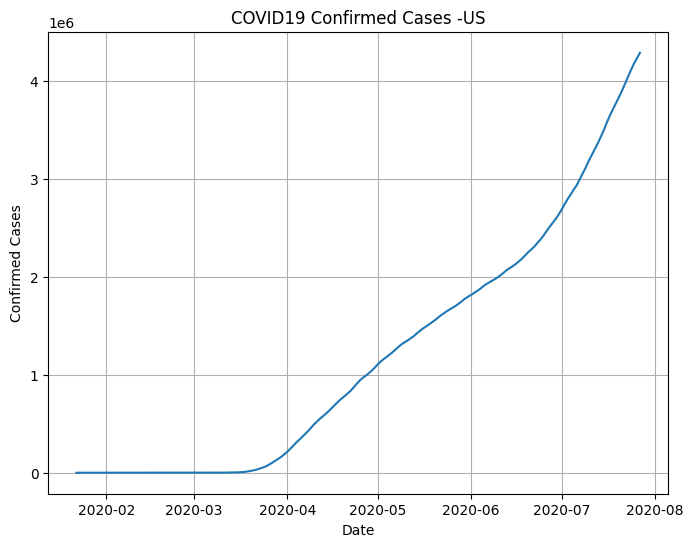

In [81]:
plt.figure(figsize=(8,6))
plt.plot(df_US['Date'],df_US['Confirmed'])
plt.title(f"COVID19 Confirmed Cases -{primary}")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.grid(True)
plt.show()



I filtered the dataset to include only US rows and plotted confirmed cases over time.

### What I Did
- Selected rows where `Country/Region = US`.  
- Converted the `Date` column to datetime.  
- Plotted confirmed case counts across the timeline.

### What the Plot Shows
- Confirmed cases steadily increased over time.  
- There are no major drops, suggesting continuous spread.  
- The overall curve shows consistent upward growth.

### Insights
Confirmed cases show a clear rising trend, indicating progressive spread across the observed dates.

## 5. Time Series Analysis: Deaths

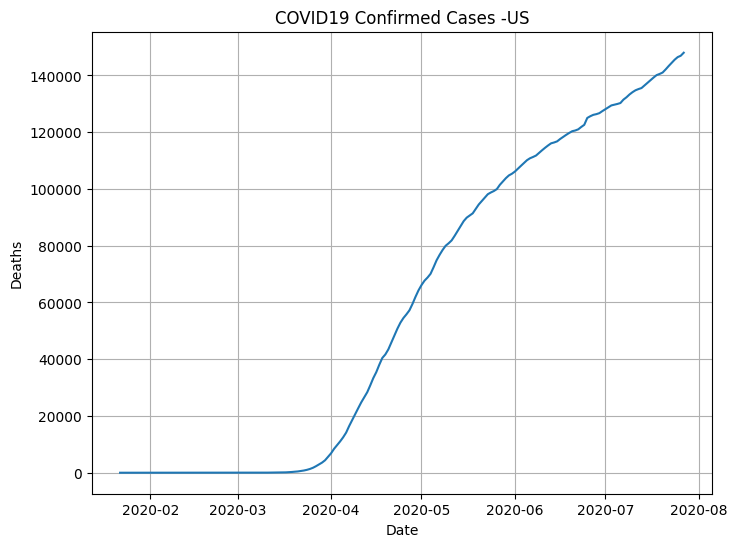

In [82]:
plt.figure(figsize=(8,6))
plt.plot(df_US['Date'],df_US['Deaths'])
plt.title(f"COVID19 Confirmed Cases -{primary}")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.grid(True)
plt.show()


I plotted the number of deaths in the US over the same timeline.

### What I Did
- Used the same filtered US dataset.  
- Plotted the `Deaths` column against time.

### What the Plot Shows
- Death counts also rise over time.  
- The slope increases more sharply after the early phase.  
- No major declines appear in the trend.

### Insights
Deaths increased alongside confirmed cases, showing that the outbreak intensified as time progressed.


In [ ]:
## 6. Key Findings and Observations

- Confirmed cases show a strong upward trend over time, indicating rapid spread.
- Deaths also increase over time but at a slower rate compared to confirmed cases.
- The time-series nature of the data highlights how outbreaks evolve and why trend analysis is critical in public health data.

## Limitations
- The analysis does not account for population size or testing rates.
- External factors such as policy changes are not included.
